# 0.1 — The Balance Game, at the computer

Do the **pen-and-paper worksheet first**. This notebook is where you check your work,
*see* what an equation actually is, and get a taste of your new superpowers.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
# `import` loads a toolbox so we can use its tools. We'll explain each as it appears.
import sys
sys.path.append("../../../tools")   # lets Python find our shared plotting helpers

import numpy as np                    # numeric arrays — THE ML workhorse
import matplotlib.pyplot as plt       # plotting
from plots import plot_functions, balance_scale

Matplotlib is building the font cache; this may take a moment.


## 1. The mental model, drawn

$3x + 2 = 14$ is a *claim of balance*:

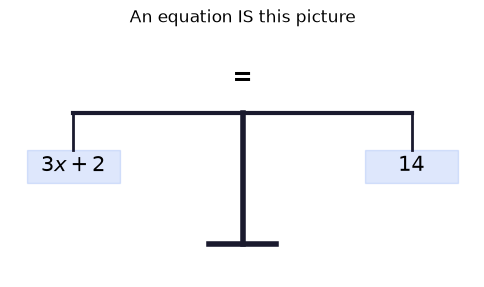

In [2]:
balance_scale("3x + 2", "14", title="An equation IS this picture")
plt.show()

## 2. Verify by substitution — your everyday superpower

You solved these on paper. Now make Python the judge: plug your answer in and ask
*"do both pans really weigh the same?"*

In [3]:
x = 4
print("3x + 2 == 14 ?", 3 * x + 2 == 14)   # `==` asks a question; `=` stores a value

3x + 2 == 14 ? True


In [4]:
# YOUR TURN — check your worksheet Part B answers (problems 5–8).
# Problem 5 is set up; add checks for 6, 7 and 8 yourself.

x = 0  # <- replace 0 with YOUR answer to problem 5
print("P5:  2x + 5 == 17 ?", 2 * x + 5 == 17)

# P6: 4x - 9 = 19        (subtraction is -, multiplication is *)
# P7: x/3 + 2 = 7        (division is /)
# P8: 10 - x = 4

P5:  2x + 5 == 17 ? False


## 3. What solving an equation LOOKS like

Here's the why nobody showed you in school: $3x + 2 = 14$ is asking
**"where does the line $y = 3x + 2$ cross the height $y = 14$?"**

Solving equations = finding where graphs meet. Every equation is a picture.

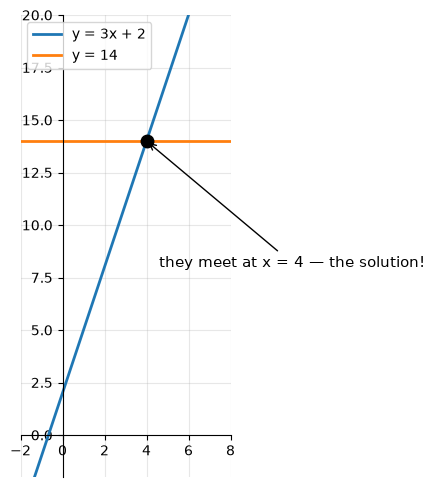

In [5]:
ax = plot_functions({
    "y = 3x + 2": lambda x: 3 * x + 2,
    "y = 14":     lambda x: 0 * x + 14,   # a flat line at height 14
}, xlim=(-2, 8), ylim=(-2, 20))
ax.plot(4, 14, "ko", markersize=9)
ax.annotate("they meet at x = 4 — the solution!", (4, 14),
            xytext=(4.6, 8), fontsize=11,
            arrowprops=dict(arrowstyle="->"))
plt.show()

## 4. sympy — the algebra referee

`sympy` does *symbolic* math: it plays the balance game itself. Use it to **check** your
pen-and-paper work — never to skip it. (The reps are the point.)

In [6]:
import sympy as sp

x = sp.symbols("x")                 # declare 'x is a symbol, not a number'
print(sp.solve(sp.Eq(3*x + 2, 14), x))   # Eq(left, right) IS the balance scale

# It handles the deep-end ones too — check your Part D attempts:
print(sp.solve(sp.Eq(3*x + 4, x + 10), x))    # problem 13

v, a, t = sp.symbols("v a t")
print(sp.solve(sp.Eq(v, a*t), a))             # problem 14 — solving for a SYMBOL

[4]
[3]
[v/t]


## 5. 🌀 A glimpse of the deep end

You now know what an equation is: a claim, transformable by legal moves.
Here's where this road leads. The rule $z \to z^2 + c$, applied over and over —
one legal move, iterated — draws this:

/var/folders/lf/jdz4bcf14ts38vz0c1511rr80000gn/T/ipykernel_10056/519976374.py:9: RuntimeWarning: overflow encountered in square
  z = z**2 + c                                  # <- the ENTIRE rule
/var/folders/lf/jdz4bcf14ts38vz0c1511rr80000gn/T/ipykernel_10056/519976374.py:9: RuntimeWarning: invalid value encountered in square
  z = z**2 + c                                  # <- the ENTIRE rule


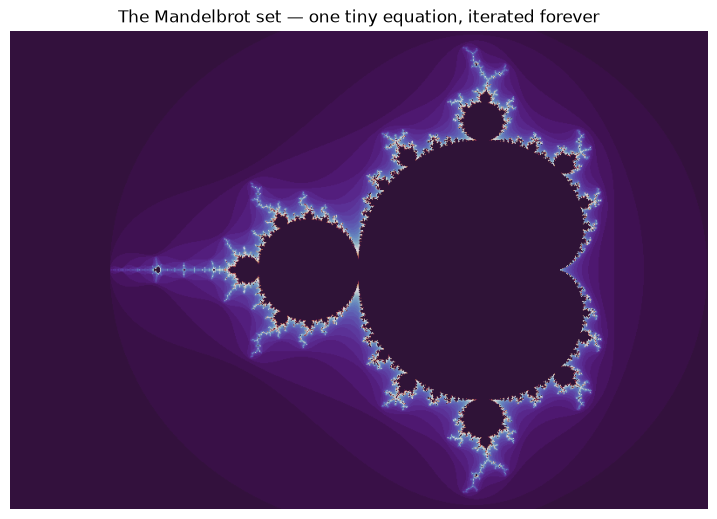

In [7]:
# Don't worry about understanding this code yet — by Module 2 you will. Just run it.
w, h = 800, 600
re = np.linspace(-2.5, 1.0, w)
im = np.linspace(-1.2, 1.2, h)
c = re[None, :] + 1j * im[:, None]
z = np.zeros_like(c)
escaped_at = np.zeros(c.shape)
for i in range(60):
    z = z**2 + c                                  # <- the ENTIRE rule
    just_escaped = (np.abs(z) > 2) & (escaped_at == 0)
    escaped_at[just_escaped] = i

plt.figure(figsize=(9, 6.5))
plt.imshow(escaped_at, cmap="twilight_shifted", extent=[-2.5, 1.0, -1.2, 1.2])
plt.title("The Mandelbrot set — one tiny equation, iterated forever")
plt.axis("off")
plt.show()

That's `z**2 + c` — a *quadratic*, the same species of equation you'll master in this module.
Simple rules, repeated, build the complexity of nature. (Neural networks are exactly this idea:
simple math, composed and repeated.)

**You'll build this image yourself, from scratch and understanding every line, in Interlude I.3.**

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 0.2 — rearranging for any symbol.*